In [1]:
# ============================================================
# Credit Card Fraud Detection
# Step 3: Feature Selection
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
df = pd.read_csv(r'C:\Users\harsh\Downloads\fraude detection\engineered_data.csv')
print("Shape:", df.shape)
df.head()


Shape: (946, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,NormalizedAmount,NormalizedTime
0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,...,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,1,-0.305938,-0.990519
1,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,...,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1,7.050480,-0.989744
2,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1,3.030594,-0.942854
3,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,...,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,1,0.514532,-0.913192
4,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,...,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1,-0.292032,-0.906929


In [3]:
X = df.drop('Class', axis=1)
Y = df['Class']

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (946, 30)
Y shape: (946,)


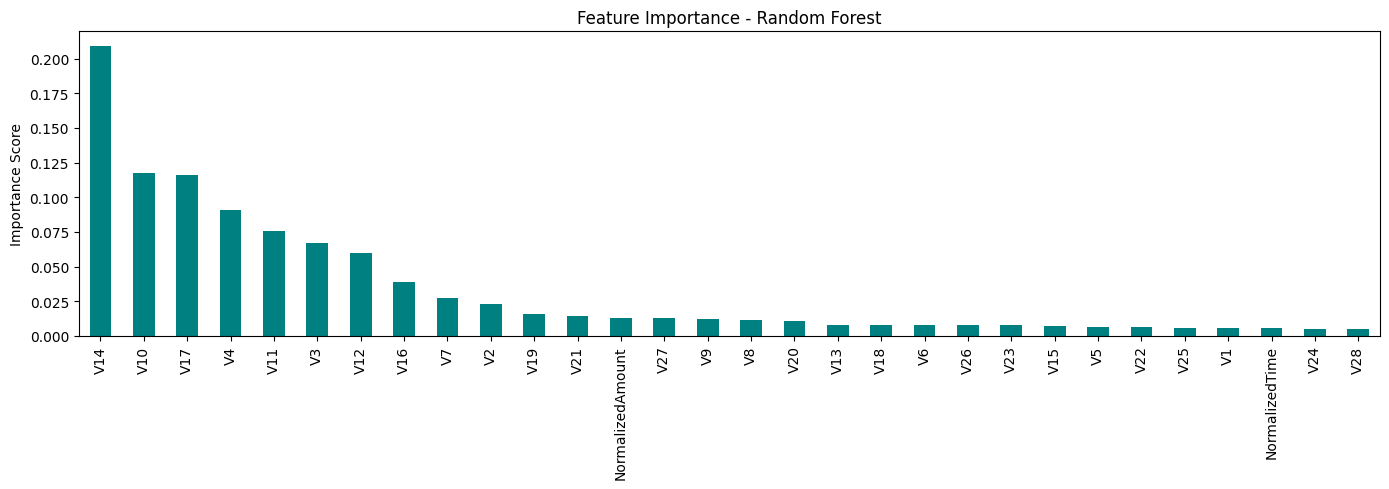


Top 10 Features:
 V14    0.209297
V10    0.117816
V17    0.115764
V4     0.090836
V11    0.075537
V3     0.066948
V12    0.059407
V16    0.038667
V7     0.026925
V2     0.022821
dtype: float64


In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, Y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(14,5))
importance.plot(kind='bar', color='teal')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:\n", importance.head(10))

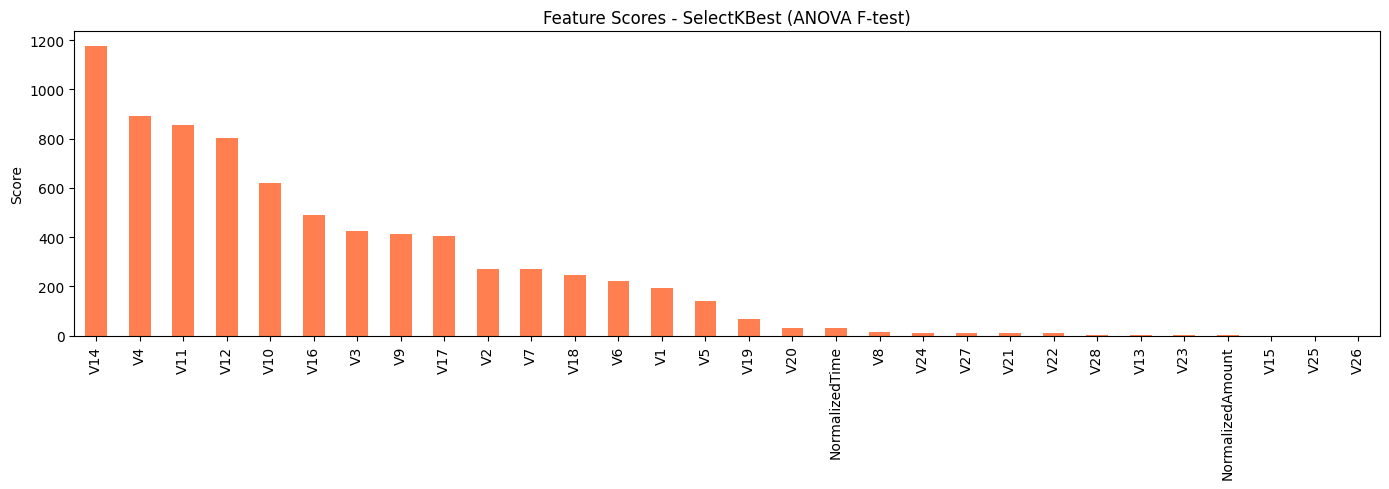


Top 15 Features:
 V14    1176.439471
V4      890.339983
V11     856.149296
V12     803.388993
V10     618.160356
V16     490.447402
V3      426.119904
V9      414.779542
V17     403.371209
V2      272.774704
V7      269.732581
V18     245.867790
V6      220.719444
V1      195.339806
V5      141.507610
dtype: float64


In [5]:
selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X, Y)

scores = pd.Series(selector.scores_, index=X.columns)
scores = scores.sort_values(ascending=False)

plt.figure(figsize=(14,5))
scores.plot(kind='bar', color='coral')
plt.title('Feature Scores - SelectKBest (ANOVA F-test)')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

print("\nTop 15 Features:\n", scores.head(15))

In [6]:
top_features = importance.head(15).index.tolist()
print("Selected Top 15 Features:", top_features)

X_selected = df[top_features]
Y = df['Class']

print("\nFinal X shape:", X_selected.shape)

Selected Top 15 Features: ['V14', 'V10', 'V17', 'V4', 'V11', 'V3', 'V12', 'V16', 'V7', 'V2', 'V19', 'V21', 'NormalizedAmount', 'V27', 'V9']

Final X shape: (946, 15)


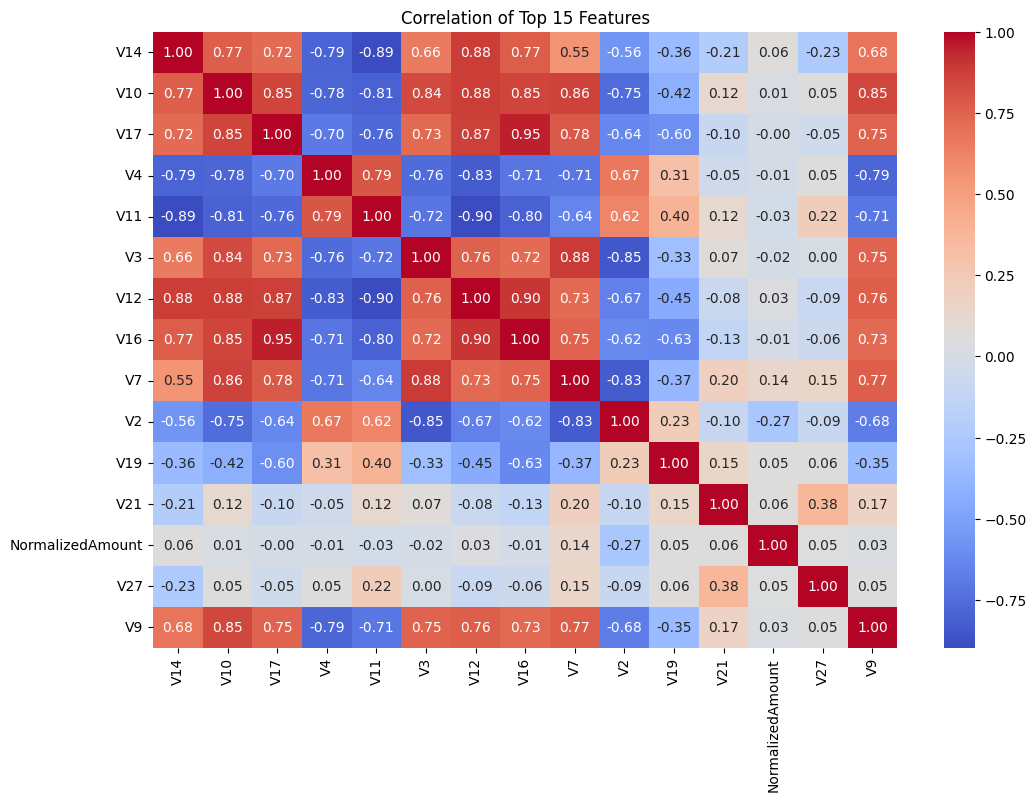

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(X_selected.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of Top 15 Features')
plt.show()

In [8]:
final_df = X_selected.copy()
final_df['Class'] = Y.values

final_df.to_csv(r'C:\Users\harsh\Downloads\fraude detection\final_data.csv', index=False)
print("Final dataset saved! ✅")
print("Shape:", final_df.shape)

Final dataset saved! ✅
Shape: (946, 16)
